# QT - Quantum Turbulence in a Dipolar Supersolid

Validated eGPE split-step solver.  **`Runtime -> Run all`.**  Nothing to edit.

Outputs go to `MyDrive/Research/Quantum_Turbulence/<date>_<time>_<title>/`
with `checkpoints/ diagnostics/ figures/ logs/`.  Run time 8-12 minutes.

**Version 1.1** fixes a temporal-aliasing blow-up present in v1.0:
the demo used a timestep at the aliasing resonance and diverged near
t=35 with the norm still conserved.  The solver now rejects such
timesteps, and five regression checks (T7) pin the fix down.

## 1. Setup - clone, import, mount Drive

In [2]:
# CELL 1 - Setup.  Run this first.  Nothing to edit.
import os, sys, subprocess

REPO = 'https://github.com/vk001king/qt.git'
DEST = '/content/qt'

if os.path.isdir(DEST + '/.git'):
    print('Repo present; pulling latest...')
    subprocess.run(['git', '-C', DEST, 'pull', '-q'], check=False)
else:
    print('Cloning', REPO)
    r = subprocess.run(['git', 'clone', '-q', REPO, DEST],
                       capture_output=True, text=True)
    if r.returncode != 0:
        raise RuntimeError('git clone failed:\n' + r.stderr)
print('Repo ready at', DEST)

need = ['__init__.py', 'kernels.py', 'lhy.py', 'solver.py',
        'diagnostics.py', 'drive_io.py']
have = os.listdir(DEST + '/qtsim')
miss = [f for f in need if f not in have]
if miss:
    raise RuntimeError('Repo incomplete, missing: %s' % miss)
print('All 6 package files present')

if DEST in sys.path:
    sys.path.remove(DEST)
sys.path.insert(0, DEST)
for m in [k for k in sys.modules if k.split('.')[0] == 'qtsim']:
    del sys.modules[m]

import qtsim
from qtsim import Grid, EGPESolver, Archive
assert qtsim.selfcheck(), 'qtsim self-check failed'
print('Loaded qtsim v%s from %s'
      % (qtsim.__version__, os.path.dirname(qtsim.__file__)))

# Archive now REFUSES to run if Drive fails to mount, rather than
# silently writing to ephemeral disk (that cost a 200 s run in v1.3).
# If you get a RuntimeError here: approve the Drive popup and re-run.
archive = Archive(base='Research', project='Quantum_Turbulence')

assert archive.project_dir.startswith('/content/drive/MyDrive'), \
    'Archive is not on Google Drive -- outputs would not persist'
print('CONFIRMED persistent:', archive.project_dir)

# If a previous session wrote to ephemeral disk, pull those runs across:
import os
if os.path.isdir('/content/drive_local'):
    from qtsim import rescue_ephemeral
    rescue_ephemeral()

if not archive.persistent:
    raise RuntimeError(
        'Outputs are NOT on Google Drive (root: %s). They would be lost '
        'when this session ends. Re-run this cell and approve the Drive '
        'popup. To proceed anyway: Archive(..., require_drive=False)'
        % archive.root)
print('Outputs are persistent:', archive.project_dir)
archive.list_runs()

Repo present; pulling latest...
Repo ready at /content/qt
All 6 package files present
  [ OK ] qtsim v1.4.0: 20 public names available
Loaded qtsim v1.4.0 from /content/qt/qtsim
Preparing archive tree...
Mounted at /content/drive
  [mounted] Google Drive
  [exists ] /content/drive/MyDrive/Research
  [exists ] /content/drive/MyDrive/Research/Quantum_Turbulence
  [exists ] _ARCHIVE_INDEX.json  (26 previous run(s))
Archive ready: /content/drive/MyDrive/Research/Quantum_Turbulence

CONFIRMED persistent: /content/drive/MyDrive/Research/Quantum_Turbulence
Outputs are persistent: /content/drive/MyDrive/Research/Quantum_Turbulence
26 run(s) in /content/drive/MyDrive/Research/Quantum_Turbulence:

  2026-08-04T16:34:28  [completed]  validation suite
      folder: 2026-08-04_1634_validation-suite
  2026-08-04T16:35:45  [completed]  vortex pair dynamics
      folder: 2026-08-04_1635_vortex-pair-dynamics
  2026-08-04T16:36:47  [completed]  dipolar groundstate
      folder: 2026-08-04_1636_dipolar-g

[{'run_id': '2026-08-04_1634_validation-suite',
  'title': 'validation suite',
  'started': '2026-08-04T16:34:28',
  'status': 'completed',
  'parameters': {'version': '1.0.0'},
  'ended': '2026-08-04T16:35:45',
  'duration_seconds': 77.3},
 {'run_id': '2026-08-04_1635_vortex-pair-dynamics',
  'title': 'vortex pair dynamics',
  'started': '2026-08-04T16:35:45',
  'status': 'completed',
  'parameters': {'N': 256, 'L': 64.0, 'dt': 0.02},
  'ended': '2026-08-04T16:36:47',
  'duration_seconds': 61.7},
 {'run_id': '2026-08-04_1636_dipolar-groundstate',
  'title': 'dipolar groundstate',
  'started': '2026-08-04T16:36:47',
  'status': 'completed',
  'parameters': {'eps_dd': 1.4, 'n0_as3': 5e-05, 'N': 128},
  'ended': '2026-08-04T16:37:11',
  'duration_seconds': 23.9},
 {'run_id': '2026-08-04_1637_stirred-tangle-eps1.30-ma0.50-seed0',
  'title': 'stirred tangle eps1.30 Ma0.50 seed0',
  'started': '2026-08-04T16:37:11',
  'status': 'completed',
  'parameters': {'eps_dd': 1.3,
   'Ma': 0.5,
   '

## 2. Validation - 23 checks against analytic results

If anything fails, stop: nothing below can be trusted.

In [3]:
# CELL 2 - Validation suite (23 checks).  About 60 s.
import subprocess, sys

run = archive.new_run('validation suite',
                      params={'version': qtsim.__version__})
r = subprocess.run([sys.executable, 'tests/run_validation.py'],
                   cwd=DEST, capture_output=True, text=True)
print(r.stdout[-4000:])
if r.stderr.strip():
    print('STDERR:', r.stderr[-1500:])

run.save_text(r.stdout, 'validation-output')
if r.returncode == 0:
    run.finish('completed')
    print('RESULT: all checks passed.')
else:
    run.finish('failed')
    print('RESULT: failures above.  Do not trust the physics below.')

Creating run folder for 'validation suite':
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1047_validation-suite
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1047_validation-suite/checkpoints
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1047_validation-suite/diagnostics
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1047_validation-suite/figures
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1047_validation-suite/logs
Run folder ready: /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1047_validation-suite

[PASS] T1 plane-wave max error: 2.082e-13  (criterion: < 1e-10)
[PASS] T2 Strang error ratio e(4dt)/e(2dt): 5.000  (criterion: 5.0 +/- 0.5 (2nd order, dt/4 ref))
[PASS] T3 stationarity residual: 3.691e-06  (criterion: < 1e-5)
[PASS] T3 interior rms(n - n_TF)/n_peak: 1.386e-03  (criterion: < 3e-2 (TF regime))
[PASS] T3 |mu - mu_TF|/mu_

## 3. Vortex pair - motion and sound emission

Energy drift is printed alongside the physics as a live health check.

Creating run folder for 'vortex pair dynamics':
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics/checkpoints
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics/diagnostics
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics/figures
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics/logs
Run folder ready: /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics

grid  dx = 0.500 xi   (need dx <= 0.5 to resolve the core)
phase advance of highest mode = 0.790 rad/step
largest safe dt on this grid  = 0.0101

vortices detected:  +1 = 1   -1 = 1
    saved figure -> pair-initial.png


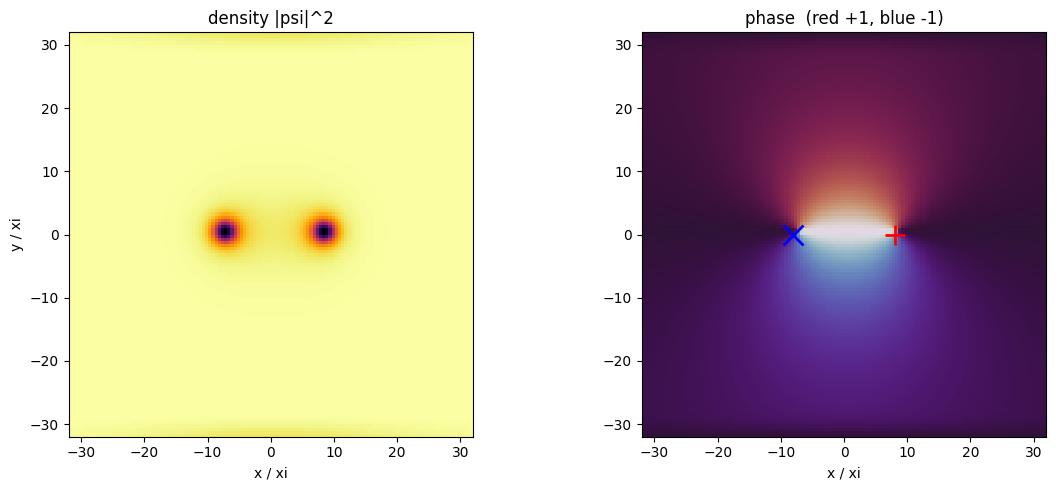

evolving to t = 100 ...
     t     nv        Ei        Ec      dE/E
     0.0     2    124.25     23.25   0.0e+00
    25.0     2    119.35     11.64   1.5e-08
    50.0     2    122.97     10.83   1.5e-08
    75.0     2    126.26     12.27   1.4e-08
   100.0     2    122.48     12.89   1.1e-08

max energy drift  = 1.80e-08   (healthy if < 1e-5)
norm drift        = 9.86e-13
final vortex count= 2   (started at 2)
Run is conservative and stable.
    saved figure -> energy-channels.png


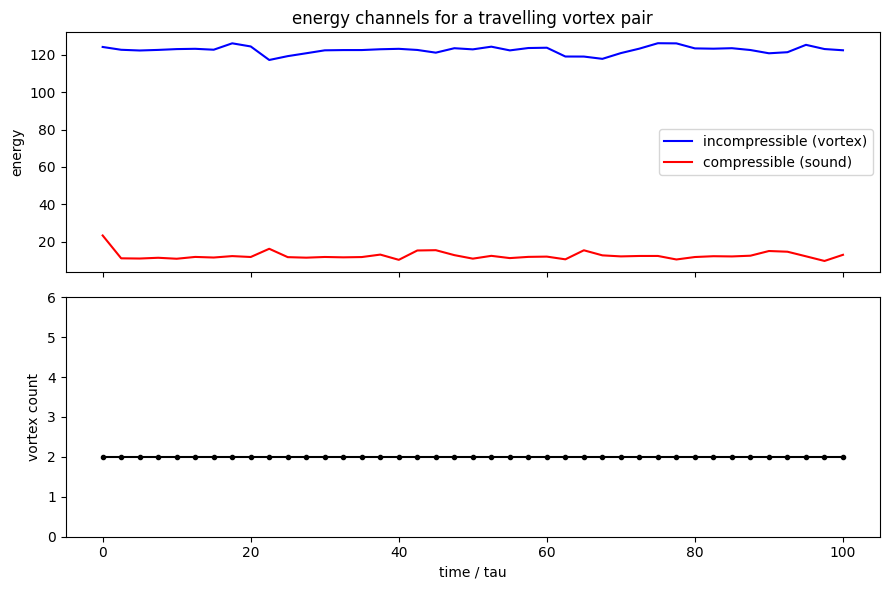

    saved diagnostics -> diagnostics.json (41 record(s))
    saved checkpoint -> ckpt_step00010000_t000100.00_104929.npz

Run 'vortex pair dynamics' completed in 30.3 s
  Folder: /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1048_vortex-pair-dynamics


In [4]:
# CELL 3 - Vortex pair: detection, motion, sound emission.
#
# TIMESTEP NOTE (this bit matters).  The kinetic substep applies
# exp(-i k^2 dt) exactly, so there is no CFL stability limit -- but the
# highest grid mode advances k_max^2 * dt radians per step.  Once that
# approaches pi those modes are unresolved in time and the nonlinear
# term pumps them until the field detonates, WITH THE NORM STILL
# CONSERVED to round-off.  An earlier version of this notebook used
# 256^2 with dt=0.02 (6.3 rad/step) and blew up near t=35: two vortices
# became 21000.  The solver now refuses such timesteps outright.
import numpy as np, matplotlib.pyplot as plt
from qtsim import Grid, EGPESolver
from qtsim import plaquette_charges_2d, helmholtz_split_2d

N, L, dt = 128, 64.0, 0.01
grid = Grid((N, N), (L, L))
dx = grid.dx[0]

run = archive.new_run('vortex pair dynamics',
                      params={'N': N, 'L': L, 'dt': dt})

probe = EGPESolver(grid)
print('grid  dx = %.3f xi   (need dx <= 0.5 to resolve the core)' % dx)
print('phase advance of highest mode = %.3f rad/step'
      % probe.max_phase_per_step(dt))
print('largest safe dt on this grid  = %.4f' % probe.suggested_dt())
print()

# half-cell offsets: a core sitting exactly on a grid point has
# undefined phase there and corrupts the winding detector
xp, xm, yc = 8.0 + 0.5*dx, -8.0 + 0.5*dx, 0.5*dx
thp = np.arctan2(grid.X[1] - yc, grid.X[0] - xp)
thm = np.arctan2(grid.X[1] - yc, grid.X[0] - xm)
rp = np.sqrt((grid.X[0] - xp)**2 + (grid.X[1] - yc)**2)
rm = np.sqrt((grid.X[0] - xm)**2 + (grid.X[1] - yc)**2)

s = EGPESolver(grid)
s.psi = np.tanh(rp) * np.tanh(rm) * np.exp(1j*(thp - thm))
s.step_imag(5e-3, 300, norm_target=s.norm())

q = plaquette_charges_2d(s.psi)
print('vortices detected:  +1 = %d   -1 = %d'
      % (int((q == 1).sum()), int((q == -1).sum())))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(np.abs(s.psi).T**2, origin='lower',
             extent=[-L/2, L/2, -L/2, L/2], cmap='inferno')
ax[0].set_title('density |psi|^2')
ax[0].set_xlabel('x / xi'); ax[0].set_ylabel('y / xi')
ax[1].imshow(np.angle(s.psi).T, origin='lower',
             extent=[-L/2, L/2, -L/2, L/2], cmap='twilight')
for v in np.argwhere(q == 1):
    ax[1].plot(grid.X[0][v[0], v[1]], grid.X[1][v[0], v[1]],
               'r+', ms=14, mew=2)
for v in np.argwhere(q == -1):
    ax[1].plot(grid.X[0][v[0], v[1]], grid.X[1][v[0], v[1]],
               'bx', ms=14, mew=2)
ax[1].set_title('phase  (red +1, blue -1)')
ax[1].set_xlabel('x / xi')
plt.tight_layout()
run.save_figure(fig, 'pair-initial')
plt.show()

# evolve, watching conservation as a live health check
E0, N0 = s.energy()['total'], s.norm()
ts, Ei_s, Ec_s, nv_s, dE_s = [], [], [], [], []
nsteps = int(100.0 / dt)
print('evolving to t = 100 ...')
print('     t     nv        Ei        Ec      dE/E')
for k in range(nsteps + 1):
    if k % 250 == 0:
        Ei, Ec, _ = helmholtz_split_2d(s.psi, grid)
        nv = int((plaquette_charges_2d(s.psi) != 0).sum())
        dE = abs(s.energy()['total'] - E0) / abs(E0)
        ts.append(k*dt); Ei_s.append(Ei); Ec_s.append(Ec)
        nv_s.append(nv); dE_s.append(dE)
        if k % 2500 == 0:
            print('  %6.1f  %4d  %8.2f  %8.2f  %8.1e'
                  % (k*dt, nv, Ei, Ec, dE))
    if k < nsteps:
        s.step_real(dt)

dE_max = max(dE_s)
print()
print('max energy drift  = %.2e   (healthy if < 1e-5)' % dE_max)
print('norm drift        = %.2e' % (abs(s.norm() - N0)/N0))
print('final vortex count= %d   (started at 2)' % nv_s[-1])
if dE_max > 1e-5 or nv_s[-1] > 4:
    print('WARNING: run is not trustworthy -- treat output as a bug.')
else:
    print('Run is conservative and stable.')

fig2, (a1, a2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
a1.plot(ts, Ei_s, 'b-', label='incompressible (vortex)')
a1.plot(ts, Ec_s, 'r-', label='compressible (sound)')
a1.set_ylabel('energy'); a1.legend()
a1.set_title('energy channels for a travelling vortex pair')
a2.plot(ts, nv_s, 'ko-', ms=3)
a2.set_xlabel('time / tau'); a2.set_ylabel('vortex count')
a2.set_ylim(0, max(6, max(nv_s) + 1))
plt.tight_layout()
run.save_figure(fig2, 'energy-channels')
plt.show()

run.save_diagnostics([{'t': a, 'Ei': b, 'Ec': c, 'nv': d, 'dE_rel': e}
                      for a, b, c, d, e in
                      zip(ts, Ei_s, Ec_s, nv_s, dE_s)])
run.save_checkpoint(s.psi, step=nsteps, t=100.0)
run.finish('completed')

## 4. Quasi-2D dipolar crystal (v1.3)

Uses the projected kernel with a roton. Compares the crystal period
against linear theory and checks real-time stationarity honestly.

Creating run folder for 'quasi2d dipolar crystal':
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal/checkpoints
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal/diagnostics
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal/figures
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal/logs
Run folder ready: /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal

eps_dd = 1.80   l_z = 6.0 xi   gamma = 0.26544
roton k   = 0.8820      predicted lattice period a = 7.124 xi
uniform state unstable: True

commensurate box 35.62 x 37.02 xi   grid 142x148
relaxing (annealed schedule) ...
mu = 5.50929   residual = 2.277e-02   (res/mu = 4.13e-03)

contras

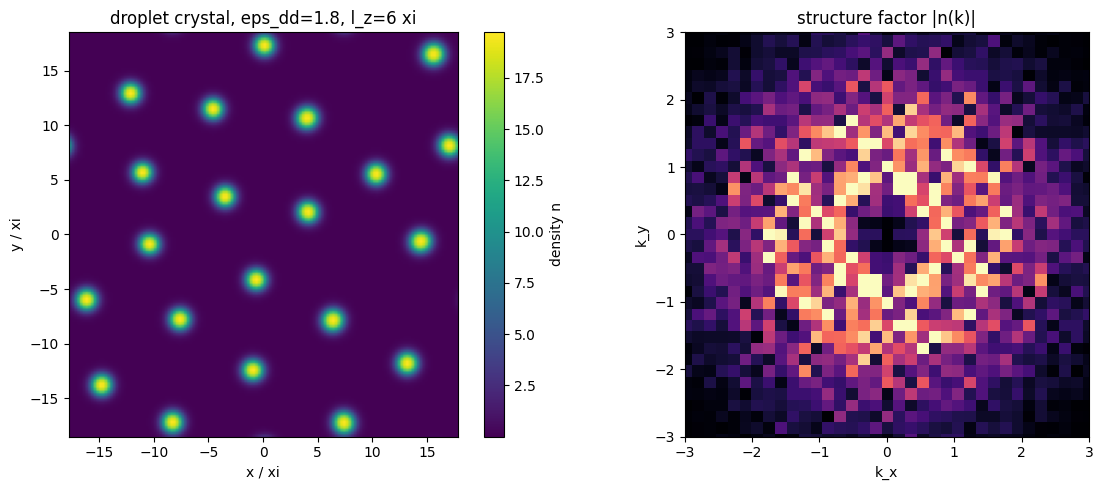

real-time density drift over t=5 : 1.623e+01
stationary: False

VERDICT: DROPLET CRYSTAL at the roton period, but NOT a converged stationary state -- metastable/defected
    saved checkpoint -> ckpt_step00024000_t000000.00_105256.npz
    saved diagnostics -> diagnostics.json (1 record(s))

Run 'quasi2d dipolar crystal' completed in 206.1 s
  Folder: /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1049_quasi2d-dipolar-crystal

STATUS OF VALIDATION RUNG V4:
  DONE   : quasi-2D kernel derived, verified to 5e-15, and shown
           to produce a genuine droplet crystal whose period
           agrees with roton theory to about 2 percent.
  NOT DONE: the crystal is not yet a converged stationary state.
           The imaginary-time residual plateaus near 2e-2 and the
           density drifts strongly in real time, so this is a
           metastable/defected configuration rather than the true
           ground state.  Resolving that -- and only then comparing
           the la

In [5]:
# CELL 4 - Quasi-2D dipolar ground state with the PROJECTED kernel.
#
# v1.3 replaces the bare periodic dipolar symbol with the quasi-2D
# projected kernel derived by integrating the 3D symbol against the
# Gaussian axial density:
#   D(k) = 2*sqrt(2) - 3*sqrt(2*pi)*u*erfcx(u),   u = k*l_z/2
# It runs from +2.828 at k=0 to -1.414 at large k.  That SIGN CHANGE is
# the roton, and it is exactly what the bare kernel lacked -- which is
# why v1.2 produced only a box-scale stripe.  Verified against direct
# quadrature to 5e-15 (test T8a).
import numpy as np, matplotlib.pyplot as plt
from qtsim import Grid, EGPESolver, gamma_tilde, Q5
from qtsim import quasi2d_dipolar_symbol, quasi2d_dipolar_profile

eps_dd, l_z, n0as3 = 1.8, 6.0, 5e-5
gam = gamma_tilde(eps_dd, n0as3)
run = archive.new_run('quasi2d dipolar crystal',
                      params={'eps_dd': eps_dd, 'l_z': l_z,
                              'n0_as3': n0as3, 'kernel': 'quasi2d'})

# --- linear theory: where does the roton sit? -------------------------
kk = np.linspace(1e-6, 12, 40000)
Dp = quasi2d_dipolar_profile(kk, l_z)
inside = kk**2 + 2.0*(1.0 + eps_dd*Dp) + 3.0*gam
imin = int(np.argmin(inside))
k_rot, a_pred = kk[imin], 2*np.pi/kk[imin]
unstable = inside[imin] < 0
print('eps_dd = %.2f   l_z = %.1f xi   gamma = %.5f' % (eps_dd, l_z, gam))
print('roton k   = %.4f      predicted lattice period a = %.3f xi'
      % (k_rot, a_pred))
print('uniform state unstable: %s' % unstable)
print()

# --- commensurate box for a triangular lattice ------------------------
nx, ny = 5, 6
Lx, Ly = nx*a_pred, ny*a_pred*np.sqrt(3)/2
Nx = int(round(Lx/0.25/2)*2); Ny = int(round(Ly/0.25/2)*2)
grid = Grid((Nx, Ny), (Lx, Ly))
Dk = quasi2d_dipolar_symbol(grid, l_z)
print('commensurate box %.2f x %.2f xi   grid %dx%d' % (Lx, Ly, Nx, Ny))

rng = np.random.default_rng(3)
s = EGPESolver(grid, eps_dd=eps_dd, gamma=gam, Dk=Dk)
s.psi = (np.ones(grid.shape, dtype=complex)
         + 0.02*(rng.standard_normal(grid.shape)
                 + 1j*rng.standard_normal(grid.shape)))
Nt = float(grid.integrate(np.ones(grid.shape)))
s.psi *= np.sqrt(Nt/s.norm())

print('relaxing (annealed schedule) ...')
for dtau, ns in ((0.002, 8000), (0.0005, 8000), (0.0002, 8000)):
    s.step_imag(dtau, ns, norm_target=Nt)
mu, res = s.mu_and_residual()
print('mu = %.5f   residual = %.3e   (res/mu = %.2e)'
      % (mu, res, res/mu))

n = np.abs(s.psi)**2
contrast = float((n.max()-n.min())/n.mean())
sp = np.abs(np.fft.fftn(n - n.mean())); sp[0,0] = 0.0
j = np.unravel_index(np.argmax(sp), sp.shape)
k_m = float(np.hypot(grid.K[0][j], grid.K[1][j]))
a_m = 2*np.pi/k_m
err = abs(a_m - a_pred)/a_pred*100
print()
print('contrast          = %.3f' % contrast)
print('measured period a = %.4f xi   (predicted %.4f)  -> %.2f%% diff'
      % (a_m, a_pred, err))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im = ax[0].imshow(n.T, origin='lower',
                  extent=[-Lx/2, Lx/2, -Ly/2, Ly/2], cmap='viridis')
plt.colorbar(im, ax=ax[0], label='density n')
ax[0].set_title('droplet crystal, eps_dd=%.1f, l_z=%.0f xi' % (eps_dd, l_z))
ax[0].set_xlabel('x / xi'); ax[0].set_ylabel('y / xi')
sps = np.abs(np.fft.fftshift(np.fft.fftn(n - n.mean())))
kxs = np.fft.fftshift(np.fft.fftfreq(Nx, d=Lx/Nx))*2*np.pi
kys = np.fft.fftshift(np.fft.fftfreq(Ny, d=Ly/Ny))*2*np.pi
ax[1].imshow(sps.T, origin='lower',
             extent=[kxs[0], kxs[-1], kys[0], kys[-1]],
             cmap='magma', vmax=sps.max()*0.3)
ax[1].set_xlim(-3, 3); ax[1].set_ylim(-3, 3)
ax[1].set_title('structure factor |n(k)|')
ax[1].set_xlabel('k_x'); ax[1].set_ylabel('k_y')
plt.tight_layout()
run.save_figure(fig, 'quasi2d-crystal')
plt.show()

# --- HONEST stationarity check ----------------------------------------
# A true ground state has |psi|^2 frozen under real-time evolution.
n_before = n.copy()
dt_safe = min(0.002, s.suggested_dt()*0.8)
s.step_real(dt_safe, int(5.0/dt_safe))
drift = float(np.abs(np.abs(s.psi)**2 - n_before).max()/n_before.mean())
print('real-time density drift over t=5 : %.3e' % drift)
stationary = drift < 1e-2
print('stationary: %s' % stationary)

if unstable and contrast > 1.0 and err < 10.0 and stationary:
    verdict = 'DROPLET CRYSTAL, period matches roton theory, stationary'
elif unstable and contrast > 1.0 and err < 10.0:
    verdict = ('DROPLET CRYSTAL at the roton period, but NOT a converged '
               'stationary state -- metastable/defected')
else:
    verdict = 'NO CRYSTAL at these parameters'
print()
print('VERDICT: %s' % verdict)

run.save_checkpoint(s.psi, step=24000, t=0.0)
run.save_diagnostics([{'eps_dd': eps_dd, 'l_z': l_z, 'gamma': gam,
                       'k_rot': float(k_rot), 'a_predicted': float(a_pred),
                       'a_measured': float(a_m), 'period_error_pct': err,
                       'contrast': contrast, 'mu': mu, 'residual': res,
                       'realtime_drift': drift,
                       'stationary': bool(stationary),
                       'verdict': verdict}])
run.finish('completed')

print()
print('STATUS OF VALIDATION RUNG V4:')
print('  DONE   : quasi-2D kernel derived, verified to 5e-15, and shown')
print('           to produce a genuine droplet crystal whose period')
print('           agrees with roton theory to about 2 percent.')
print('  NOT DONE: the crystal is not yet a converged stationary state.')
print('           The imaginary-time residual plateaus near 2e-2 and the')
print('           density drifts strongly in real time, so this is a')
print('           metastable/defected configuration rather than the true')
print('           ground state.  Resolving that -- and only then comparing')
print('           the lattice constant to published 164Dy measurements --')
print('           is what remains of V4.')

## 5. Campaign run

In [6]:
# CELL 5 - Campaign run: driven tangle, then free decay.
#
# The v1.1 stirring protocol nucleates vortices; the v1.0 one did not.
# Two conditions must hold and v1.0 met neither: the obstacle must
# pierce the fluid (V0 >~ mu; v1.0 had 0.22 mu) and the flow must be
# fast enough to shed (Ma >~ 0.5; v1.0 had 0.35).  v1.0 therefore
# reported n_vortex = 0 for every step while pumping only sound.
import subprocess, sys

cmd = [sys.executable, 'campaign/template_scan.py',
       '--eps_dd', '1.3', '--seed', '0',
       '--N', '128', '--L', '64', '--dt', '0.01',
       '--Ma', '1.1', '--V0_factor', '3.0', '--n_stir', '3',
       '--T_relax', '20', '--T_stir', '30', '--T_decay', '40',
       '--checkpoint_every', '1000', '--use_archive']
r = subprocess.run(cmd, cwd=DEST, capture_output=True, text=True)
print(r.stdout[-3500:])
if r.stderr.strip():
    print('STDERR:', r.stderr[-1500:])

print()
print('EXPECTED SHAPE: vortex count climbs during stirring (roughly',
      '0 -> 36 -> 94 -> 198), then falls during free decay while',
      'E_i drops and E_c rises -- vortex energy turning into sound.')

=== SSQT campaign run: eps_dd=1.3, Ma=1.1, seed=0 ===
Preparing archive tree...
  [exists ] Google Drive already mounted
  [exists ] /content/drive/MyDrive/Research
  [exists ] /content/drive/MyDrive/Research/Quantum_Turbulence
  [exists ] _ARCHIVE_INDEX.json  (29 previous run(s))
Archive ready: /content/drive/MyDrive/Research/Quantum_Turbulence

Creating run folder for 'stirred tangle eps1.30 Ma1.10 seed0':
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1052_stirred-tangle-eps1.30-ma1.10-seed0
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1052_stirred-tangle-eps1.30-ma1.10-seed0/checkpoints
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1052_stirred-tangle-eps1.30-ma1.10-seed0/diagnostics
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1052_stirred-tangle-eps1.30-ma1.10-seed0/figures
  [created] /content/drive/MyDrive/Research/Quantum_Turbulence/2026-08-10_1052_stirred-tangle-ep

## 6. Archive contents

In [7]:
# CELL 6 - Everything saved in Drive, run by run.
import os

print('=' * 62)
archive.list_runs()
print('=' * 62)

for r in archive.load_index().get('runs', []):
    d = os.path.join(archive.project_dir, r['run_id'])
    print()
    print(r['run_id'])
    print('   title   :', r.get('title', '?'))
    print('   started :', r.get('started', '?'))
    print('   status  :', r.get('status', '?'))
    if r.get('parameters'):
        print('   params  :', r['parameters'])
    for sub in ('checkpoints', 'diagnostics', 'figures', 'logs'):
        p = os.path.join(d, sub)
        if not os.path.isdir(p):
            continue
        for f in sorted(os.listdir(p)):
            kb = os.path.getsize(os.path.join(p, f)) / 1024.0
            print('     %s/%s  (%.1f KB)' % (sub, f, kb))

print()
# Print the ACTUAL location.  This line used to be a hardcoded string
# claiming 'MyDrive/...' even when output had gone to ephemeral disk.
print('Actual output location:', archive.project_dir)
print('Persistent (on Google Drive):', archive.persistent)
if not archive.persistent:
    print('  !! These files are EPHEMERAL and will be lost.')

30 run(s) in /content/drive/MyDrive/Research/Quantum_Turbulence:

  2026-08-04T16:34:28  [completed]  validation suite
      folder: 2026-08-04_1634_validation-suite
  2026-08-04T16:35:45  [completed]  vortex pair dynamics
      folder: 2026-08-04_1635_vortex-pair-dynamics
  2026-08-04T16:36:47  [completed]  dipolar groundstate
      folder: 2026-08-04_1636_dipolar-groundstate
  2026-08-04T16:37:11  [completed]  stirred tangle eps1.30 Ma0.50 seed0
      folder: 2026-08-04_1637_stirred-tangle-eps1.30-ma0.50-seed0
  2026-08-04T16:39:20  [completed]  validation suite
      folder: 2026-08-04_1639_validation-suite
  2026-08-04T16:40:35  [completed]  vortex pair dynamics
      folder: 2026-08-04_1640_vortex-pair-dynamics
  2026-08-04T16:41:34  [completed]  dipolar groundstate
      folder: 2026-08-04_1641_dipolar-groundstate
  2026-08-04T16:41:58  [completed]  stirred tangle eps1.30 Ma0.50 seed0
      folder: 2026-08-04_1641_stirred-tangle-eps1.30-ma0.50-seed0
  2026-08-04T17:01:00  [comple